# Environment Setup

Layer 2 turns the Layer 1 forecast into an actionable, equitable, and explainable distribution plan. The quantitative core is fully deterministic: a mixed integer program allocates scarce IFK stock across facilities under supply, storage, and cold chain constraints, and a transshipment program moves surplus stock between facilities to cover residual deficits. The language model never decides quantities. It only verbalizes decisions that the optimizer already made, grounded in an exact additive decomposition of each allocation priority, and every generated justification passes a numeric faithfulness check before it is accepted.

## Drive Mount and Base Path

In [1]:
"""Mount Google Drive when running on Colab. Outside Colab the notebook falls
back to a local directory so the full pipeline can be tested end to end."""

import os

try:
    from google.colab import drive
    drive.mount('/content/drive')

    """Base path untuk Google Drive storage"""
    base_path = '/content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton'
    IN_COLAB = True
except ModuleNotFoundError:
    base_path = os.environ.get(
        'MATERNALINK_DATA_ROOT',
        os.path.abspath(os.path.join(os.getcwd(), '..', 'drive_local')),
    )
    IN_COLAB = False

DATA_DIRS = {
    name: os.path.join(base_path, 'data', name)
    for name in [
        'master', 'transactional', 'layer0_output',
        'layer1_mock', 'layer2_output', 'audio_demo', 'eval',
    ]
}
for path in DATA_DIRS.values():
    os.makedirs(path, exist_ok=True)

print(f'Base path: {base_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base path: /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton


## Runtime Detection and Dependencies

The optimizer runs everywhere. The LLM explanation path requires a CUDA device; on CPU runtimes the engine falls back to deterministic template explanations built from the same decision factors, so the notebook always completes with a fully justified plan.

In [2]:
"""Detect the runtime, install Colab dependencies, and choose the explainer path."""

import subprocess
import sys

if IN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'pulp', 'transformers>=4.51', 'accelerate', 'bitsandbytes'],
        check=True,
    )

import pulp

try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except ModuleNotFoundError:
    torch = None
    HAS_CUDA = False

USE_LLM = HAS_CUDA and os.environ.get('MATERNALINK_FORCE_BASELINE', '') != '1'
LLM_MODEL_ID = 'Qwen/Qwen3-4B-Instruct-2507'

print(f'solver: {pulp.LpSolverDefault.name}')
print(f'explainer path: {"LLM " + LLM_MODEL_ID if USE_LLM else "deterministic templates (CPU)"}')

solver: PULP_CBC_CMD
explainer path: LLM Qwen/Qwen3-4B-Instruct-2507


# Load Inputs

Inputs are the Layer 1 forecast (or its mock), the IFK stock position, facility and drug master data, and six months of stockout history used as an equity factor.

In [3]:
"""Load forecast, stock position, master data, and stockout history."""

import json
import math

import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

RUN_ID = 'L2-2026-01'


def read_csv(folder, filename):
    df = pd.read_csv(os.path.join(DATA_DIRS[folder], filename))
    for col in ('period', 'forecast_period'):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df


facilities = read_csv('master', 'facilities.csv')
drugs = read_csv('master', 'drugs.csv')
forecast = read_csv('layer1_mock', 'l1_forecast_mock.csv')
ifk_stock = read_csv('layer1_mock', 'ifk_stock_mock.csv')
stock_monthly = read_csv('transactional', 'stock_monthly.csv')

FORECAST_PERIOD = forecast['forecast_period'].iloc[0]
HISTORY_END = stock_monthly['period'].max()

stockout_history = (
    stock_monthly[stock_monthly['period'] > HISTORY_END - pd.DateOffset(months=6)]
    .groupby(['facility_id', 'drug_id'])['stockout_flag']
    .sum()
    .reset_index(name='stockouts_6m')
)

if forecast['is_mock'].all():
    print('NOTE: running on the mock Layer 1 forecast, swap l1_forecast_mock.csv for the real output when available')
print(f'forecast period {FORECAST_PERIOD.date()}, {len(forecast)} forecast rows')

NOTE: running on the mock Layer 1 forecast, swap l1_forecast_mock.csv for the real output when available
forecast period 2026-01-01, 900 forecast rows


# Priority Weight Construction

Each facility and drug pair receives a multiplicative priority weight

w = w_category x w_access x w_stockout x w_dos x w_mmr

built from five auditable factors: drug urgency category (emergency 3.0, essential 2.0, routine 1.0), accessibility score (worst 1.5, middle 1.2, best 1.0), stockout history (one plus 0.2 per stockout in the last six months, capped at 2.0), days of stock urgency (one plus the shortfall against a thirty day target), and regional maternal mortality (one plus the ratio to the district maximum). Because the weight is a product, its logarithm decomposes additively per factor, which later yields an exact attribution of why any allocation was prioritized.

In [4]:
"""Assemble the allocation input table with all priority factors."""

W_CATEGORY = {'emergency': 3.0, 'essential': 2.0, 'routine': 1.0}
W_ACCESS = {1: 1.5, 2: 1.2, 3: 1.0}
DOS_TARGET = 30.0

mmr_max = facilities['regional_mmr'].max()

allocation_input = (
    forecast
    .merge(drugs[['drug_id', 'drug_name', 'category', 'requires_cold_chain']], on='drug_id')
    .merge(
        facilities[[
            'facility_id', 'name', 'remoteness', 'accessibility_score',
            'regional_mmr', 'has_cold_chain', 'storage_capacity_total',
            'cold_chain_capacity',
        ]],
        on='facility_id',
    )
    .merge(stockout_history, on=['facility_id', 'drug_id'], how='left')
)
allocation_input['stockouts_6m'] = allocation_input['stockouts_6m'].fillna(0).astype(int)
allocation_input['requirement'] = allocation_input['total_requirement']

daily_need = allocation_input['forecast_demand'] / 30.0
allocation_input['days_of_stock'] = np.where(
    daily_need > 0, allocation_input['current_stock'] / daily_need.replace(0, np.nan), np.inf,
).round(1)

allocation_input['w_category'] = allocation_input['category'].map(W_CATEGORY)
allocation_input['w_access'] = allocation_input['accessibility_score'].map(W_ACCESS)
allocation_input['w_stockout'] = np.minimum(2.0, 1.0 + 0.2 * allocation_input['stockouts_6m'])
allocation_input['w_dos'] = 1.0 + np.maximum(
    0.0, (DOS_TARGET - np.minimum(allocation_input['days_of_stock'], DOS_TARGET)) / DOS_TARGET,
)
allocation_input['w_mmr'] = 1.0 + allocation_input['regional_mmr'] / mmr_max

WEIGHT_COLUMNS = ['w_category', 'w_access', 'w_stockout', 'w_dos', 'w_mmr']
allocation_input['priority_score'] = allocation_input[WEIGHT_COLUMNS].prod(axis=1).round(3)

allocation_input = allocation_input[allocation_input['requirement'] > 0].reset_index(drop=True)
print(f'{len(allocation_input)} facility drug cells with positive requirement')

647 facility drug cells with positive requirement


## Composite Priority Score

The highest priority cells should read like the product thesis: emergency drugs for hard to reach facilities with recent stockouts and depleted shelves in high mortality areas.

In [5]:
"""Preview the most urgent allocation cells."""

preview_columns = [
    'facility_id', 'name', 'drug_name', 'category', 'requirement', 'current_stock',
    'days_of_stock', 'accessibility_score', 'stockouts_6m', 'priority_score',
]
allocation_input.nlargest(10, 'priority_score')[preview_columns]

,facility_id,name,drug_name,category,requirement,current_stock,days_of_stock,accessibility_score,stockouts_6m,priority_score
95,PKM-005,Puskesmas Iteng,Quinine,essential,78,0,0.0,1,3,18.047
96,PKM-005,Puskesmas Iteng,Clindamycin,essential,11,0,0.0,1,3,18.047
97,PKM-005,Puskesmas Iteng,Artemisinin Combination Therapy,essential,48,0,0.0,1,3,18.047
98,PKM-005,Puskesmas Iteng,High Dose Iron,essential,161,0,0.0,1,2,15.791
104,PKM-005,Puskesmas Iteng,Amoxicillin,essential,53,0,0.0,1,2,15.791
105,PKM-005,Puskesmas Iteng,Cephalexin,essential,12,0,0.0,1,2,15.791
482,PKM-024,Puskesmas Ponggeok,Quinine,essential,59,0,0.0,1,1,14.400
483,PKM-024,Puskesmas Ponggeok,Clindamycin,essential,8,0,0.0,1,1,14.400
489,PKM-024,Puskesmas Ponggeok,Insulin,emergency,8,2,12.0,1,0,14.400
494,PKM-024,Puskesmas Ponggeok,Levothyroxine,essential,36,0,0.0,1,1,14.400


# Central Allocation MILP

Decision variables x[p, d] are the integer units of drug d shipped from the IFK to facility p, bounded by the facility requirement. Per drug equity variables z[d] capture the minimum coverage ratio across facilities needing that drug.

The objective maximizes priority weighted coverage plus an equity bonus

maximize sum over p, d of w[p, d] x[p, d] / requirement[p, d] plus alpha times the sum over d of z[d]

subject to supply per drug, storage headroom per facility, cold chain headroom per facility, the per cell demand cap, and z[d] at most the coverage of every facility requiring drug d. The equity term prevents the weighted objective from starving low weight facilities entirely: raising the worst coverage of a drug is worth alpha, so the optimizer spreads scarce stock instead of concentrating it.

In [6]:
"""Build and solve the central allocation MILP for a given supply vector."""

ALPHA_EQUITY = 25.0
CBC_OPTIONS = dict(msg=0, timeLimit=120, gapRel=0.001)

SUPPLY = ifk_stock.set_index('drug_id')['available_stock'].to_dict()

facility_totals = forecast.groupby('facility_id')['current_stock'].sum().to_dict()
cc_drug_ids = set(drugs.loc[drugs['requires_cold_chain'], 'drug_id'])
cc_current = (
    forecast[forecast['drug_id'].isin(cc_drug_ids)]
    .groupby('facility_id')['current_stock'].sum().to_dict()
)
facility_meta = facilities.set_index('facility_id')

STORAGE_HEADROOM = {
    fid: max(0, int(facility_meta.loc[fid, 'storage_capacity_total'] - facility_totals.get(fid, 0)))
    for fid in facilities['facility_id']
}
CC_HEADROOM = {
    fid: max(0, int(facility_meta.loc[fid, 'cold_chain_capacity'] - cc_current.get(fid, 0)))
    for fid in facilities['facility_id']
}


def solve_central_allocation(supply, label):
    """Solve the MILP and return (allocation dataframe, solver status)."""
    cells_df = allocation_input
    prob = pulp.LpProblem(f'central_allocation_{label}', pulp.LpMaximize)

    x = {}
    for row in cells_df.itertuples():
        if row.requires_cold_chain and not row.has_cold_chain:
            continue
        x[(row.facility_id, row.drug_id)] = pulp.LpVariable(
            f'x_{row.facility_id}_{row.drug_id}', lowBound=0,
            upBound=int(row.requirement), cat='Integer',
        )

    drug_cells = {}
    for (fid, did) in x:
        drug_cells.setdefault(did, []).append(fid)
    z = {
        did: pulp.LpVariable(f'z_{did}', lowBound=0, upBound=1)
        for did in drug_cells
    }

    weight = cells_df.set_index(['facility_id', 'drug_id'])
    prob += (
        pulp.lpSum(
            weight.loc[key, 'priority_score'] * var / weight.loc[key, 'requirement']
            for key, var in x.items()
        )
        + ALPHA_EQUITY * pulp.lpSum(z.values())
    )

    for did, fids in drug_cells.items():
        prob += pulp.lpSum(x[(fid, did)] for fid in fids) <= supply.get(did, 0)
        for fid in fids:
            req = weight.loc[(fid, did), 'requirement']
            prob += z[did] * req <= x[(fid, did)]

    for fid in facilities['facility_id']:
        fid_vars = [var for (f, d), var in x.items() if f == fid]
        if fid_vars:
            prob += pulp.lpSum(fid_vars) <= STORAGE_HEADROOM[fid]
        cc_vars = [var for (f, d), var in x.items() if f == fid and d in cc_drug_ids]
        if cc_vars:
            prob += pulp.lpSum(cc_vars) <= CC_HEADROOM[fid]

    prob.solve(pulp.PULP_CBC_CMD(**CBC_OPTIONS))
    status = pulp.LpStatus[prob.status]

    allocated = {key: int(var.value() or 0) for key, var in x.items()}
    result = cells_df.copy()
    result['allocated'] = result.apply(
        lambda r: allocated.get((r['facility_id'], r['drug_id']), 0), axis=1,
    )
    return result, status

In [7]:
"""Solve the main allocation run and assemble the allocation table."""

allocation_result, solver_status = solve_central_allocation(SUPPLY, 'main')
print(f'solver status: {solver_status}')
assert solver_status == 'Optimal'

allocation_result['coverage_ratio'] = (
    allocation_result['allocated'] / allocation_result['requirement']
).round(3)
allocation_result['unmet_demand'] = (
    allocation_result['requirement'] - allocation_result['allocated']
)
post_daily_need = allocation_result['forecast_demand'] / 30.0
allocation_result['post_allocation_days_of_stock'] = np.where(
    post_daily_need > 0,
    ((allocation_result['current_stock'] + allocation_result['allocated'])
     / post_daily_need.replace(0, np.nan)),
    np.inf,
)
allocation_result['post_allocation_days_of_stock'] = (
    allocation_result['post_allocation_days_of_stock'].replace(np.inf, 999.0).round(1)
)

l2_allocation = allocation_result.assign(run_id=RUN_ID)[[
    'run_id', 'facility_id', 'drug_id', 'requirement', 'allocated',
    'coverage_ratio', 'priority_score', 'post_allocation_days_of_stock',
    'unmet_demand',
]]

total_alloc = l2_allocation['allocated'].sum()
total_req = l2_allocation['requirement'].sum()
print(f'allocated {total_alloc} of {total_req} required units ({total_alloc / total_req:.0%})')
print(f'unmet after central allocation: {l2_allocation.unmet_demand.sum()} units')

solver status: Optimal
allocated 14890 of 19555 required units (76%)
unmet after central allocation: 4665 units


# Inter Facility Redistribution

Some facilities hold legacy stock above their own requirement while neighbors face deficits the IFK could not cover. A transshipment program per drug moves surplus to deficit at minimum routing cost. Because no direct road matrix exists between facilities, the route cost is proxied through the hub as the sum of both distances to the IFK plus a penalty for poor accessibility, and the proxy is recorded as a documented modeling assumption. Only surpluses of at least five units are considered worth shipping, and cold chain drugs can only flow to cold chain equipped receivers, which holds by construction since incompatible facilities carry no requirement.

In [8]:
"""Solve a max flow min cost transshipment per drug over surplus and deficit."""

MIN_SURPLUS_TO_SHIP = 5
ACCESS_PENALTY_KM = 15.0

post = allocation_result.copy()
post['available'] = post['current_stock'] + post['allocated']
post['surplus'] = np.maximum(0, post['available'] - post['requirement'])
post['deficit'] = np.maximum(0, post['requirement'] - post['available'])

dist = facility_meta['distance_to_ifk_km'].to_dict()
acc = facility_meta['accessibility_score'].to_dict()


def route_cost(i, j):
    """Hub proxy route cost: both spokes plus accessibility penalties."""
    return round(
        dist[i] + dist[j] + ACCESS_PENALTY_KM * ((3 - acc[i]) + (3 - acc[j])), 1,
    )


transfer_rows = []
for drug_id, group in post.groupby('drug_id'):
    sources = group[group['surplus'] >= MIN_SURPLUS_TO_SHIP]
    sinks = group[group['deficit'] >= 1]
    if sources.empty or sinks.empty:
        continue

    prob = pulp.LpProblem(f'redistribution_{drug_id}', pulp.LpMaximize)
    t = {}
    costs = {}
    for src in sources.itertuples():
        for snk in sinks.itertuples():
            key = (src.facility_id, snk.facility_id)
            costs[key] = route_cost(*key)
            t[key] = pulp.LpVariable(
                f't_{drug_id}_{key[0]}_{key[1]}', lowBound=0, cat='Integer',
            )

    big = 10.0 * max(costs.values())
    prob += pulp.lpSum((big - costs[key]) * var for key, var in t.items())
    for src in sources.itertuples():
        prob += pulp.lpSum(
            t[(src.facility_id, snk.facility_id)] for snk in sinks.itertuples()
        ) <= int(src.surplus)
    for snk in sinks.itertuples():
        prob += pulp.lpSum(
            t[(src.facility_id, snk.facility_id)] for src in sources.itertuples()
        ) <= int(snk.deficit)

    prob.solve(pulp.PULP_CBC_CMD(**CBC_OPTIONS))
    assert pulp.LpStatus[prob.status] == 'Optimal'

    for (src_id, snk_id), var in t.items():
        qty = int(var.value() or 0)
        if qty > 0:
            transfer_rows.append({
                'run_id': RUN_ID,
                'drug_id': drug_id,
                'from_facility_id': src_id,
                'to_facility_id': snk_id,
                'transfer_qty': qty,
                'route_cost_index': costs[(src_id, snk_id)],
                'reason': f'surplus at {src_id} covers unmet requirement at {snk_id}',
            })

l2_redistribution = pd.DataFrame(
    transfer_rows,
    columns=['run_id', 'drug_id', 'from_facility_id', 'to_facility_id',
             'transfer_qty', 'route_cost_index', 'reason'],
)
transferred = int(l2_redistribution['transfer_qty'].sum()) if len(l2_redistribution) else 0
print(f'{len(l2_redistribution)} transfers moving {transferred} units')
l2_redistribution.head()

37 transfers moving 462 units


,run_id,drug_id,from_facility_id,to_facility_id,transfer_qty,route_cost_index,reason
0,L2-2026-01,OBT-001,PKM-030,PKM-018,23,106.3,surplus at PKM-030 covers unmet requirement at...
1,L2-2026-01,OBT-002,PKM-013,PKM-018,3,116.6,surplus at PKM-013 covers unmet requirement at...
2,L2-2026-01,OBT-002,PKM-013,PKM-022,2,48.0,surplus at PKM-013 covers unmet requirement at...
3,L2-2026-01,OBT-003,PKM-030,PKM-003,14,36.3,surplus at PKM-030 covers unmet requirement at...
4,L2-2026-01,OBT-004,PKM-030,PKM-009,130,142.1,surplus at PKM-030 covers unmet requirement at...


# Decision Factor Attribution

The multiplicative weight decomposes exactly in log space: log w equals the sum of the per factor logs. Each cell therefore gets an additive, SHAP like breakdown of why it ranked where it did, with no approximation involved.

In [9]:
"""Exact additive attribution of every allocation priority."""

FACTOR_VALUE_COLUMNS = {
    'drug_category': 'category',
    'accessibility': 'accessibility_score',
    'stockout_history': 'stockouts_6m',
    'days_of_stock': 'days_of_stock',
    'regional_mmr': 'regional_mmr',
}
FACTOR_WEIGHT_COLUMNS = {
    'drug_category': 'w_category',
    'accessibility': 'w_access',
    'stockout_history': 'w_stockout',
    'days_of_stock': 'w_dos',
    'regional_mmr': 'w_mmr',
}

factor_rows = []
for row in allocation_result.itertuples():
    for factor, value_col in FACTOR_VALUE_COLUMNS.items():
        weight = getattr(row, FACTOR_WEIGHT_COLUMNS[factor])
        factor_rows.append({
            'run_id': RUN_ID,
            'facility_id': row.facility_id,
            'drug_id': row.drug_id,
            'factor': factor,
            'factor_value': str(getattr(row, value_col)),
            'weight_contribution': round(math.log(weight), 4),
        })

l2_decision_factors = pd.DataFrame(factor_rows)
print(f'{len(l2_decision_factors)} factor attribution rows')
l2_decision_factors.head()

3235 factor attribution rows


,run_id,facility_id,drug_id,factor,factor_value,weight_contribution
0,L2-2026-01,PKM-001,OBT-001,drug_category,essential,0.6931
1,L2-2026-01,PKM-001,OBT-001,accessibility,1,0.4055
2,L2-2026-01,PKM-001,OBT-001,stockout_history,0,0.0000
3,L2-2026-01,PKM-001,OBT-001,days_of_stock,37.5,0.0000
4,L2-2026-01,PKM-001,OBT-001,regional_mmr,464.8,0.5732


# Explanation Engine

The explainer receives, per decision, a JSON payload containing only optimizer outputs and the sorted factor contributions, and must write two to four plain sentences for IFK staff. Hard rules: it may not invent, recompute, or alter any number. Every generated text passes a numeric faithfulness check, where each number appearing in the text must literally appear in the payload; a violating generation is retried once and then replaced by the deterministic template, so the published plan is faithful by construction. On CPU runtimes the deterministic template is used directly.

In [10]:
"""Load the explanation model on GPU runtimes."""

llm_model = None
llm_tokenizer = None

if USE_LLM:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
    )
    llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)
    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        quantization_config=quant_config,
        device_map='auto',
    )
    llm_model.eval()
    print(f'loaded {LLM_MODEL_ID}')
else:
    print('LLM explainer disabled, deterministic templates will be used')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

loaded Qwen/Qwen3-4B-Instruct-2507


In [11]:
"""Payload construction, faithfulness checking, and both explainer paths."""

import re

EXPLAINER_SYSTEM_PROMPT = (
    'You write short allocation justifications for district pharmacy (IFK) staff. '
    'You receive a JSON payload describing one decision made by a deterministic optimizer. '
    'Explain in two to four plain professional English sentences why this decision was made, '
    'citing the dominant priority factors. Use only numbers that literally appear in the payload. '
    'Never invent, recompute, or round numbers. Do not use emojis or bullet points.'
)

FACTOR_PHRASES = {
    'drug_category': 'the drug urgency category',
    'accessibility': 'poor road accessibility',
    'stockout_history': 'repeated recent stockouts',
    'days_of_stock': 'a depleted stock position',
    'regional_mmr': 'high regional maternal mortality',
}

district_requirement = forecast.groupby('drug_id')['total_requirement'].sum().to_dict()
drug_names = drugs.set_index('drug_id')['drug_name'].to_dict()
facility_names = facilities.set_index('facility_id')['name'].to_dict()


def numeric_tokens(text):
    """All numeric tokens in a string, commas stripped."""
    return set(re.findall(r'\d+(?:\.\d+)?', text.replace(',', '')))


def build_allocation_payload(row):
    """Grounding payload for one allocation decision."""
    factors = sorted(
        (
            {
                'factor': factor,
                'value': str(getattr(row, FACTOR_VALUE_COLUMNS[factor])),
                'contribution': round(math.log(getattr(row, FACTOR_WEIGHT_COLUMNS[factor])), 2),
            }
            for factor in FACTOR_VALUE_COLUMNS
        ),
        key=lambda f: f['contribution'], reverse=True,
    )
    supply_pct = int(round(
        100 * SUPPLY.get(row.drug_id, 0) / max(1, district_requirement[row.drug_id])
    ))
    return {
        'facility': facility_names[row.facility_id],
        'remoteness': row.remoteness,
        'drug': drug_names[row.drug_id],
        'category': row.category,
        'requirement_units': int(row.requirement),
        'allocated_units': int(row.allocated),
        'coverage_pct': int(round(100 * row.allocated / row.requirement)),
        'unmet_units': int(row.requirement - row.allocated),
        'district_supply_pct_of_requirement': supply_pct,
        'priority_factors': factors[:3],
    }


def template_allocation_text(payload):
    """Deterministic justification assembled only from payload values."""
    leads = [FACTOR_PHRASES[f['factor']] for f in payload['priority_factors'][:2]]
    text = (
        f"{payload['facility']} receives {payload['allocated_units']} of the "
        f"{payload['requirement_units']} required units of {payload['drug']} "
        f"({payload['coverage_pct']} percent coverage). "
        f"The allocation was prioritized mainly due to {leads[0]} and {leads[1]}. "
        f"District supply covers {payload['district_supply_pct_of_requirement']} percent "
        f"of the total requirement for this drug, so full coverage is not possible this cycle."
    )
    if payload['unmet_units'] > 0:
        text += (
            f" The remaining {payload['unmet_units']} units are deferred to "
            f"inter facility redistribution or the next resupply."
        )
    return text


def template_transfer_text(payload):
    """Deterministic justification for one redistribution transfer."""
    return (
        f"{payload['transfer_qty']} units of {payload['drug']} move from "
        f"{payload['from_facility']} to {payload['to_facility']}. "
        f"The sender holds stock above its own requirement while the receiver "
        f"still faces a deficit after the central allocation, and this route has "
        f"the lowest cost index ({payload['route_cost_index']}) among available pairs."
    )


def generate_llm_text(payload):
    """One LLM generation for a payload."""
    messages = [
        {'role': 'system', 'content': EXPLAINER_SYSTEM_PROMPT},
        {'role': 'user', 'content': json.dumps(payload)},
    ]
    encoded = llm_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors='pt', return_dict=True,
    ).to(llm_model.device)
    with torch.no_grad():
        output = llm_model.generate(
            **encoded, max_new_tokens=180, do_sample=False,
            pad_token_id=llm_tokenizer.eos_token_id,
        )
    prompt_length = encoded['input_ids'].shape[1]
    return llm_tokenizer.decode(output[0][prompt_length:], skip_special_tokens=True).strip()


def faithful_explanation(payload, template_fn):
    """LLM text accepted only if numerically faithful, else template fallback."""
    if not USE_LLM:
        return template_fn(payload), 'template'
    allowed = numeric_tokens(json.dumps(payload))
    for _ in range(2):
        text = generate_llm_text(payload)
        if numeric_tokens(text) <= allowed:
            return text, f'{LLM_MODEL_ID}-4bit'
    return template_fn(payload), 'template-fallback'

## Justification Generation

Justifications are generated for the most decision relevant slice: the highest priority allocations with residual scarcity, every redistribution transfer, and one district level summary.

In [12]:
"""Generate justifications for top allocations, transfers, and the summary."""

N_ALLOCATION_EXPLANATIONS = 12

explained = allocation_result[allocation_result['unmet_demand'] > 0].nlargest(
    N_ALLOCATION_EXPLANATIONS, 'priority_score',
)

justification_rows = []
for row in explained.itertuples():
    payload = build_allocation_payload(row)
    text, generator = faithful_explanation(payload, template_allocation_text)
    justification_rows.append({
        'run_id': RUN_ID,
        'target_type': 'allocation',
        'facility_id': row.facility_id,
        'drug_id': row.drug_id,
        'justification_text': text,
        'generator': generator,
    })

for row in l2_redistribution.itertuples():
    payload = {
        'drug': drug_names[row.drug_id],
        'from_facility': facility_names[row.from_facility_id],
        'to_facility': facility_names[row.to_facility_id],
        'transfer_qty': int(row.transfer_qty),
        'route_cost_index': float(row.route_cost_index),
    }
    text, generator = faithful_explanation(payload, template_transfer_text)
    justification_rows.append({
        'run_id': RUN_ID,
        'target_type': 'redistribution',
        'facility_id': row.to_facility_id,
        'drug_id': row.drug_id,
        'justification_text': text,
        'generator': generator,
    })

summary_payload = {
    'forecast_period': str(FORECAST_PERIOD.date()),
    'total_requirement_units': int(l2_allocation['requirement'].sum()),
    'total_allocated_units': int(l2_allocation['allocated'].sum()),
    'unmet_after_allocation_units': int(l2_allocation['unmet_demand'].sum()),
    'units_redistributed': int(l2_redistribution['transfer_qty'].sum()) if len(l2_redistribution) else 0,
    'facilities_served': int((l2_allocation.groupby('facility_id')['allocated'].sum() > 0).sum()),
}


def template_summary_text(payload):
    return (
        f"For {payload['forecast_period']}, the IFK allocates "
        f"{payload['total_allocated_units']} of {payload['total_requirement_units']} "
        f"required units across {payload['facilities_served']} facilities. "
        f"{payload['unmet_after_allocation_units']} units remain unmet after central allocation, "
        f"of which {payload['units_redistributed']} units are covered by inter facility transfers."
    )


text, generator = faithful_explanation(summary_payload, template_summary_text)
justification_rows.append({
    'run_id': RUN_ID,
    'target_type': 'summary',
    'facility_id': None,
    'drug_id': None,
    'justification_text': text,
    'generator': generator,
})

l2_justifications = pd.DataFrame(justification_rows)
print(f'{len(l2_justifications)} justifications generated')
print()
print(l2_justifications.iloc[0]['justification_text'])

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


50 justifications generated

Puskesmas Cancar receives 22 of the 30 required units of Spiramycin (73 percent coverage). The allocation was prioritized mainly due to the drug urgency category and a depleted stock position. District supply covers 64 percent of the total requirement for this drug, so full coverage is not possible this cycle. The remaining 8 units are deferred to inter facility redistribution or the next resupply.


# Persistence

## Output Tables and Dashboard JSON

The four output tables serve analysis and audit, while l2_output.json is the single payload a dashboard or API integration consumes.

In [13]:
"""Persist Layer 2 tables and the consolidated dashboard payload."""


def write_csv(df, folder, filename):
    path = os.path.join(DATA_DIRS[folder], filename)
    df.to_csv(path, index=False)
    print(f'wrote {len(df):>6} rows -> {path}')


write_csv(l2_allocation, 'layer2_output', 'l2_allocation.csv')
write_csv(l2_redistribution, 'layer2_output', 'l2_redistribution.csv')
write_csv(l2_decision_factors, 'layer2_output', 'l2_decision_factors.csv')
write_csv(l2_justifications, 'layer2_output', 'l2_justifications.csv')

justification_lookup = {
    (row.target_type, row.facility_id, row.drug_id): row.justification_text
    for row in l2_justifications.itertuples()
}

factor_lookup = {}
for row in allocation_result.itertuples():
    factor_lookup[(row.facility_id, row.drug_id)] = [
        {
            'factor': factor,
            'value': str(getattr(row, FACTOR_VALUE_COLUMNS[factor])),
            'contribution': round(math.log(getattr(row, FACTOR_WEIGHT_COLUMNS[factor])), 4),
        }
        for factor in FACTOR_VALUE_COLUMNS
    ]

allocation_entries = []
for row in allocation_result.itertuples():
    allocation_entries.append({
        'facility_id': row.facility_id,
        'facility_name': facility_names[row.facility_id],
        'drug_id': row.drug_id,
        'drug_name': drug_names[row.drug_id],
        'category': row.category,
        'requirement': int(row.requirement),
        'allocated': int(row.allocated),
        'coverage_ratio': round(float(row.allocated / row.requirement), 3),
        'unmet': int(row.requirement - row.allocated),
        'priority_score': float(row.priority_score),
        'factors': sorted(
            factor_lookup[(row.facility_id, row.drug_id)],
            key=lambda f: f['contribution'], reverse=True,
        ),
        'justification': justification_lookup.get(
            ('allocation', row.facility_id, row.drug_id),
        ),
    })

redistribution_entries = [
    {
        'drug_id': row.drug_id,
        'drug_name': drug_names[row.drug_id],
        'from_facility_id': row.from_facility_id,
        'to_facility_id': row.to_facility_id,
        'transfer_qty': int(row.transfer_qty),
        'route_cost_index': float(row.route_cost_index),
        'justification': justification_lookup.get(
            ('redistribution', row.to_facility_id, row.drug_id),
        ),
    }
    for row in l2_redistribution.itertuples()
]

coverage_by_drug = (
    l2_allocation.groupby('drug_id')
    .apply(lambda g: g['allocated'].sum() / g['requirement'].sum(), include_groups=False)
)

l2_output = {
    'run_id': RUN_ID,
    'forecast_period': str(FORECAST_PERIOD.date()),
    'summary': {
        **summary_payload,
        'min_drug_coverage': round(float(coverage_by_drug.min()), 3),
        'n_transfers': len(l2_redistribution),
        'district_summary': justification_lookup.get(('summary', None, None)),
    },
    'allocations': allocation_entries,
    'redistribution': redistribution_entries,
}

with open(os.path.join(DATA_DIRS['layer2_output'], 'l2_output.json'), 'w') as f:
    json.dump(l2_output, f, indent=2)
print('wrote l2_output.json')

wrote    647 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/layer2_output/l2_allocation.csv
wrote     37 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/layer2_output/l2_redistribution.csv
wrote   3235 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/layer2_output/l2_decision_factors.csv
wrote     50 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/layer2_output/l2_justifications.csv
wrote l2_output.json


# Feasibility Checks

## Supply Conservation and Constraint Compliance

Every constraint the MILP claims to honor is re verified on the solved values, independently of the solver.

In [14]:
"""Independent post solve verification of all hard constraints."""

merged = allocation_result

by_drug = merged.groupby('drug_id')['allocated'].sum()
for drug_id, total in by_drug.items():
    assert total <= SUPPLY.get(drug_id, 0), f'supply violated for {drug_id}'

assert (merged['allocated'] <= merged['requirement']).all()
assert (merged['allocated'] >= 0).all()

by_facility = merged.groupby('facility_id')['allocated'].sum()
for fid, total in by_facility.items():
    assert total <= STORAGE_HEADROOM[fid], f'storage capacity violated for {fid}'

cc_alloc = merged[merged['drug_id'].isin(cc_drug_ids)]
for fid, total in cc_alloc.groupby('facility_id')['allocated'].sum().items():
    assert total <= CC_HEADROOM[fid], f'cold chain capacity violated for {fid}'

incompatible_alloc = merged[
    merged['requires_cold_chain'] & ~merged['has_cold_chain']
]['allocated'].sum()
assert incompatible_alloc == 0, 'cold chain incompatible allocation found'

if len(l2_redistribution):
    sent = l2_redistribution.groupby(['drug_id', 'from_facility_id'])['transfer_qty'].sum()
    surplus_map = post.set_index(['drug_id', 'facility_id'])['surplus']
    for (drug_id, fid), qty in sent.items():
        assert qty <= surplus_map.loc[(drug_id, fid)], 'transfer exceeds surplus'
    received = l2_redistribution.groupby(['drug_id', 'to_facility_id'])['transfer_qty'].sum()
    deficit_map = post.set_index(['drug_id', 'facility_id'])['deficit']
    for (drug_id, fid), qty in received.items():
        assert qty <= deficit_map.loc[(drug_id, fid)], 'transfer exceeds deficit'

unmet_before = int(l2_allocation['unmet_demand'].sum())
unmet_after = unmet_before - (
    int(l2_redistribution['transfer_qty'].sum()) if len(l2_redistribution) else 0
)
print(f'unmet demand: {unmet_before} units after allocation, {unmet_after} after redistribution')
print('all feasibility checks passed')

unmet demand: 4665 units after allocation, 4203 after redistribution
all feasibility checks passed


## Equity and Sensitivity Diagnostics

Two properties must hold for the equity narrative to be credible. First, facilities with the worst accessibility should not end up with worse coverage than well connected ones. Second, since IFK supply is fixed per drug, scarcity induced triage happens across facilities competing for the same drug, so when supply tightens the high priority facilities must retain coverage better than low priority ones.

In [15]:
"""Equity check: coverage by accessibility group."""

equity = (
    merged.assign(weighted_alloc=merged['allocated'], weighted_req=merged['requirement'])
    .groupby('accessibility_score')
    .apply(lambda g: g['weighted_alloc'].sum() / g['weighted_req'].sum(), include_groups=False)
    .rename('coverage')
)
print('coverage by accessibility score (1 = worst access):')
print(equity.round(3).to_string())
assert equity.loc[1] >= equity.loc[3] - 0.02, 'low access facilities are underserved'

coverage by accessibility score (1 = worst access):
accessibility_score
1    0.864
2    0.755
3    0.710


                supply x0.5  supply x0.9  supply x1.0
access score 1        0.819        0.860        0.864
access score 2        0.374        0.701        0.755
access score 3        0.142        0.576        0.710


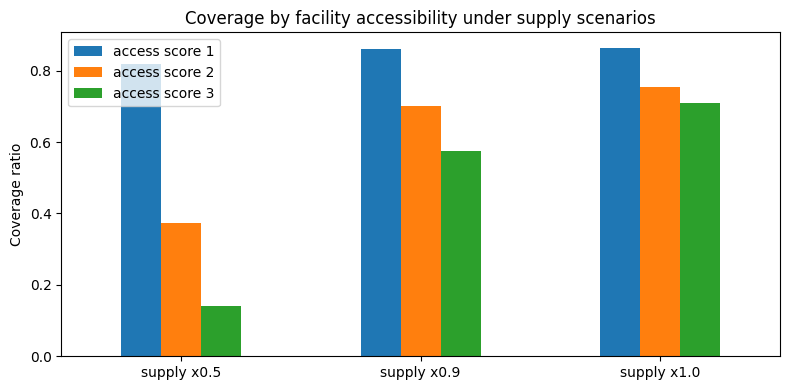

equity and sensitivity diagnostics passed


In [16]:
"""Sensitivity: re solve under tighter supply and inspect facility triage."""

import matplotlib.pyplot as plt

scenario_results = {}
for scale in (0.5, 0.9, 1.0):
    scenario_supply = {d: int(s * scale) for d, s in SUPPLY.items()}
    result, status = solve_central_allocation(scenario_supply, f'scale_{int(scale * 100)}')
    assert status == 'Optimal'
    scenario_results[scale] = (
        result.groupby('accessibility_score')
        .apply(lambda g: g['allocated'].sum() / g['requirement'].sum(), include_groups=False)
    )

sensitivity = pd.DataFrame(scenario_results).round(3)
sensitivity.columns = [f'supply x{c}' for c in sensitivity.columns]
sensitivity.index = [f'access score {i}' for i in sensitivity.index]
print(sensitivity.to_string())

tight = scenario_results[0.5]
assert tight.loc[1] > tight.loc[3], 'triage failed: hard to reach facilities not prioritized under scarcity'

sensitivity.T.plot.bar(figsize=(8, 4), rot=0)
plt.title('Coverage by facility accessibility under supply scenarios')
plt.ylabel('Coverage ratio')
plt.tight_layout()
plt.show()

print('equity and sensitivity diagnostics passed')